In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text 
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn import preprocessing
import re 
import seaborn as sns

In [2]:
df_admits = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\diagnoses_icd.csv.gz', compression='gzip')
df_transfers = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar.csv.gz', compression='gzip')
#df_medi_details = pd.read_csv(r'S:\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar_detail.csv.gz', compression='gzip')


In [3]:
df_admits = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\diagnoses_icd.csv.gz', compression='gzip')
#df_transfers = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar.csv.gz', compression='gzip')
#df_medi_details = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar_detail.csv.gz', compression='gzip')


In [4]:
#print(df_admits.head(10))
#print(df_diagnosis.head(10))
#print(df_icd_proc.head(10))
#print(df_icd_diagnosis.head(10))
df_pat.head(10)

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13
5,10000102,F,27,2136,2008 - 2010,NaN
6,10000108,M,25,2163,2014 - 2016,NaN
7,10000115,M,24,2154,2017 - 2019,NaN
8,10000117,F,48,2174,2008 - 2010,NaN
9,10000161,M,60,2163,2020 - 2022,NaN


In [35]:
# Data Checks

#df_admits.isna().any() # check which columns have NaN
df_admits.loc[:,df_admits.isna().any()]
#df_admits[df_admits['admission_location'] == '']
#pd.reset_option('display.max_rows')


,deathtime,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,edregtime,edouttime
0,NaN,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,2180-05-06 19:17:00,2180-05-06 23:30:00
1,NaN,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,2180-06-26 15:54:00,2180-06-26 21:31:00
2,NaN,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,2180-08-05 20:58:00,2180-08-06 01:44:00
3,NaN,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,2180-07-23 05:54:00,2180-07-23 14:00:00
4,NaN,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,2160-03-03 21:55:00,2160-03-04 06:26:00
...,...,...,...,...,...,...,...,...,...
546023,NaN,P13JMH,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,2149-01-08 09:11:00,2149-01-08 18:12:00
546024,NaN,P38XL8,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,2147-07-17 17:18:00,2147-07-18 17:34:00
546025,2164-09-17 13:42:00,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,2164-09-10 11:09:00,2164-09-10 14:46:00
546026,NaN,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,2164-07-24 21:16:00,2164-07-25 01:20:00


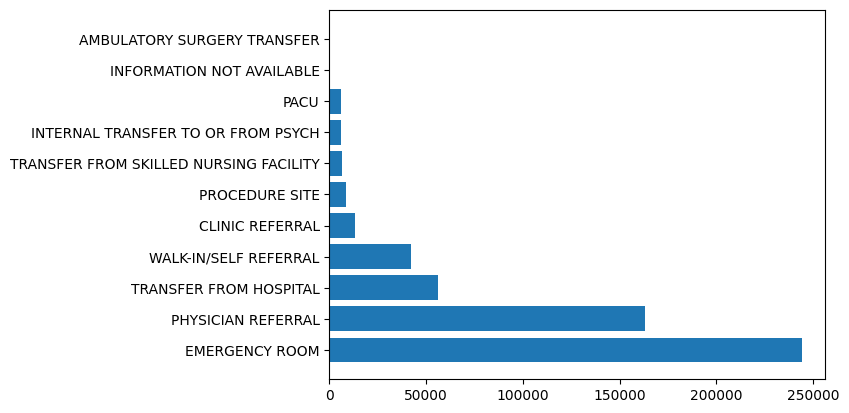

In [6]:
plt.barh(df_admits['admission_location'].value_counts().index,df_admits.admission_location.value_counts().values)
plt.show() # to check for missing values 

In [3]:
# Join diagnosis, admissions and procs
df_admit_icd = pd.merge(df_admits,df_diagnosis,how = 'left', on = 'hadm_id')
df_admit_diagnosis = pd.merge(df_admit_icd,df_icd_diagnosis,how = 'left', on = 'icd_code')
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_icd_proc,how = 'left', on = 'icd_code')
df_admit_diagnosis.drop(columns= ['subject_id_y'], inplace = True)
df_admit_diagnosis.rename(columns={'long_title_x': 'icd_diagnosis_name','long_title_y':'proc_name','subject_id_x':'subject_id'}, inplace=True)
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_pat[['subject_id', 'anchor_age','gender']],how = 'left', on = 'subject_id')

In [4]:
pd.set_option('display.max_columns', None)
df_admit_diagnosis.head(5)

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,1.0,5723,9.0,9.0,Portal hypertension,NaN,NaN,52,F
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,2.0,78959,9.0,9.0,Other ascites,NaN,NaN,52,F
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,3.0,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,NaN,52,F
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,4.0,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,NaN,52,F
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,5.0,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,52,F


In [ ]:
# Next stage
# 1 - Group text fields
# 2 - Enocode catgeorical features
# 3 - Assign appointment readimission instance flags

In [117]:
# 1. 
# 
# Check for how many diagnosis that exist - will need to group diagnosis first for easier encoding
#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', None)
pd.reset_option('display.max_rows')

#df_admit_diagnosis.proc_name.value_counts()

In [5]:
#pd.reset_option('display.max_rows')
# Replace all NaN with 'No Diagnosis'
df_admit_diagnosis['icd_diagnosis_name'] = df_admit_diagnosis['icd_diagnosis_name'].fillna('No Diagnosis')
df_admit_diagnosis['proc_name'] = df_admit_diagnosis['proc_name'].fillna('No Procedure')
#df_admit_diagnosis['icd_code'] = df_admit_diagnosis['icd_code'].fillna('0')
df_admit_diagnosis[df_admit_diagnosis['proc_name'].isna()]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender


In [6]:
#df_admit_diagnosis['diagnosis_proc'] = df_admit_diagnosis['icd_diagnosis_name'] + ' ' + df_admit_diagnosis['proc_name']
#df_admit_diagnosis['diagnosis_proc'] = df_admit_diagnosis['diagnosis_proc'].apply(lambda x: x.lower())
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,1.0,5723,9.0,9.0,Portal hypertension,NaN,No Procedure,52,F
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,2.0,78959,9.0,9.0,Other ascites,NaN,No Procedure,52,F
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,3.0,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,52,F
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,4.0,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,52,F
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,5.0,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,52,F


In [61]:
df_admit_diagnosis.icd_diagnosis_name.value_counts()

icd_diagnosis_name
Unspecified essential hypertension                                                                                                    102368
Hyperlipidemia, unspecified                                                                                                            84570
Essential (primary) hypertension                                                                                                       83775
Other and unspecified hyperlipidemia                                                                                                   67293
Acute kidney failure, unspecified                                                                                                      65020
                                                                                                                                       ...  
History of extracorporeal membrane oxygenation (ECMO)                                                                                  

"First, we manually merged similar diagnostic nouns according to prior knowledge, from 891 to 405. However, the data were obviously separated and sparse. For instance, none of the negative samples had a sudden cardiac arrest or sudden respiratory arrest diagnosis. Next, we only kept the diagnosis that appeared in more than 5% population. Finally, PCA was proposed for the remaining variables. The first 17 PCs that could explain 98.2% variance of the original sample were selected. Regression analysis was carried out on the samples after dimensionality reduction. The explanation of variables was achieved by counting the weight of the original variables on each PC."

https://pmc.ncbi.nlm.nih.gov/articles/PMC9898833/

In [7]:
def custom_preprocessor(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  # remove all digits
    text = re.sub(r'[^a-z\s]', '', text)  # keep only letters and whitespace
    return text


In [54]:
# Apply K-means clustering for text columns
# Inital vectorizer step is key for good clustering - add in custom conditions for stop words and removal of common words

my_stop_words = ['disease','history','type','term','episode','eyes', 'face', 'facial','mouth','home','legs','pain','procedure','weight','adult','child']
combined_stop_words = list(text.ENGLISH_STOP_WORDS.union(my_stop_words))

vectorizer = TfidfVectorizer(
                            preprocessor=custom_preprocessor,
                            stop_words=combined_stop_words, 
                            ngram_range=(1, 1),     # combines phrases  
                            max_df=0.80,            # removes words in column/document that appear in > 80% of doc
                            max_features=3000 
                             )          
#vectorized_words_diagnosis = vectorizer_d.fit_transform(df_admit_diagnosis['icd_diagnosis_name'])
vectorized_words = vectorizer.fit_transform(df_admit_diagnosis['icd_diagnosis_name'])


In [ ]:
print(vectorized_words)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40364587 stored elements and shape (6484759, 3000)>
  Coords	Values
  (0, 2131)	0.6413570030718132
  (0, 1251)	0.38611239662901836
  (0, 2132)	0.6630070978354136
  (1, 248)	1.0
  (2, 527)	0.3832872294687358
  (2, 1538)	0.3295964596624426
  (2, 1661)	0.24691725647332236
  (2, 122)	0.3340617599465191
  (2, 528)	0.38524074269770786
  (2, 1543)	0.4590282883713681
  (2, 1662)	0.4612746287645318
  (3, 2795)	0.11574772011173562
  (3, 2962)	0.3255047007093367
  (3, 1200)	0.33743684563023163
  (3, 1197)	0.33845092425739953
  (3, 575)	0.3231004552069389
  (3, 2867)	0.37868214962747576
  (3, 2965)	0.3637348980370549
  (3, 1203)	0.381498007911771
  (3, 1198)	0.3558070003434419
  (4, 496)	0.22921350165004994
  (4, 120)	0.434770249829972
  (4, 1889)	0.3349395379908469
  (4, 531)	0.28271347844487654
  (4, 497)	0.43478716744463425
  :	:
  (6484754, 1757)	0.29380691340335063
  (6484754, 231)	0.2918483709228993
  (6484754, 641)	0.336395035895

In [55]:
tfidf_cols = vectorizer.get_feature_names_out()
print(tfidf_cols[1:100])

['abdominal' 'abducens' 'abducent' 'abnormal' 'abnormalities'
 'abnormality' 'abortion' 'abrasion' 'abscess' 'absence' 'absorption'
 'abuse' 'accessory' 'accident' 'accidental' 'accidentally' 'accidents'
 'acetabulum' 'acetonuria' 'achalasia' 'achieved' 'achilles' 'acid'
 'acidbase' 'acidosis' 'acne' 'acquired' 'acromial' 'acromioclavicular'
 'acting' 'actinic' 'action' 'activated' 'active' 'activities' 'activity'
 'acute' 'adequate' 'adhesions' 'adhesive' 'adiposity' 'adjustment'
 'administered' 'administration' 'admission' 'adnexa' 'adolescents'
 'adrenal' 'adrenocortical' 'adultpediatric' 'adults' 'adverse'
 'aeruginosa' 'affecting' 'affective' 'aftercare' 'agenesis' 'agent'
 'agents' 'agerelated' 'agitans' 'agitation' 'agonists' 'agoraphobia'
 'agranulocytosis' 'air' 'airway' 'alcohol' 'alcoholic' 'alcoholinduced'
 'alcoholism' 'alighting' 'alkalosis' 'allergens' 'allergic' 'allergy'
 'allterrain' 'alopecia' 'alphaadrenoreceptor' 'alphaantitrypsin'
 'alteration' 'alterations' 'alte

In [56]:
# this step is needed to reduce data size (dimensionality reduction) due to too many features & sparse matrix
svd = TruncatedSVD(
    n_components=50, random_state=42
    )
reduced_data = svd.fit_transform(vectorized_words)


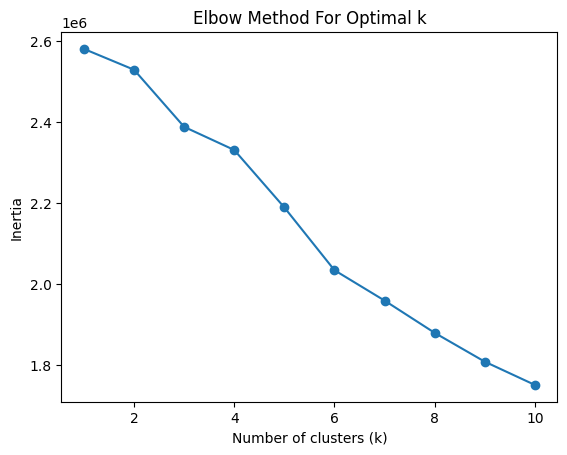

In [57]:
# Use Elbow Method to determine the number of clusters to use

inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(reduced_data)  # use reduced TF-IDF data (from TruncatedSVD)
    inertias.append(kmeans.inertia_)

plt.plot(K, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [58]:
num_clusters=10
kmeans = KMeans(n_clusters=num_clusters, n_init=5, max_iter=500, random_state=42)
kmeans.fit(vectorized_words)

KMeans(max_iter=500, n_clusters=10, n_init=5, random_state=42)

C:\Users\smahmood\AppData\Local\Temp\ipykernel_18944\727227039.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


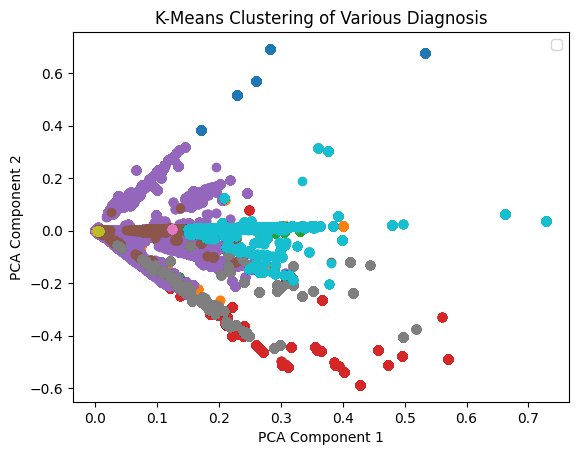

In [59]:
for i in range(num_clusters):
    plt.scatter(reduced_data[kmeans.labels_ == i, 0], 
                reduced_data[kmeans.labels_ == i, 1], 
                )

plt.legend()
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of Various Diagnosis')
plt.show()

In [ ]:
df_admit_diagnosis['diagnosis_cluster'] = kmeans.labels_
#add proc cluster here
print(df_admit_diagnosis['diagnosis_cluster'].value_counts())

diagnosis_proc_cluster
0    5692273
1     606343
2     186143
Name: count, dtype: int64


In [24]:
df_admit_diagnosis.head()

,subject_id_x,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag,subject_id_y,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,diagnosis_proc,diagnosis_proc_cluster
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,1.0,5723,9.0,9.0,Portal hypertension,NaN,No Procedure,portal hypertension no procedure,0
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,2.0,78959,9.0,9.0,Other ascites,NaN,No Procedure,other ascites no procedure,0
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,3.0,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,cirrhosis of liver without mention of alcohol ...,0
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,4.0,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,unspecified viral hepatitis c without hepatic ...,0
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0,10000032.0,5.0,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,"chronic airway obstruction, not elsewhere clas...",0


In [ ]:
df_admit_diagnosis.drop(columns = ['icd_version_y','subject_id_y','icd_version','edregtime','edouttime','deathtime','admit_provider_id','marital_status','hospital_expire_flag',
                                          'seq_num','icd_code','icd_version','language','icd_diagnosis_name','proc_name','diagnosis_proc'],inplace = True)
df_admit_diagnosis.rename(columns={'icd_version_x': 'icd_version','subject_id_x':'subject_id'}, inplace=True)

In [28]:
# Encoding diagnosis table

# combine diagnosis cluster into one admisison per row

df_admit_diagnosis_encoded = pd.get_dummies(df_admit_diagnosis, columns=['diagnosis_proc_cluster'], dtype = int)
df_admit_diagnosis_encoded.head(5)  

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,1,0,0
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,1,0,0
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,1,0,0
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,1,0,0
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WHITE,1,0,0


In [30]:
df_admit_diagnosis_encoded = df_admit_diagnosis_encoded.groupby(['hadm_id', 'subject_id']).agg({
     'admission_type':'first',
     'admission_location': 'first',
     'discharge_location':'first',
     'admittime':'first',
     'dischtime':'first',
     'insurance':'first',
     'race':'first',
     'diagnosis_proc_cluster_0':'sum',
     'diagnosis_proc_cluster_1':'sum',
     'diagnosis_proc_cluster_2':'sum',
     }).reset_index()
df_admit_diagnosis_encoded.head(5)  

,hadm_id,subject_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2
0,20000019,10467237,EW EMER.,EMERGENCY ROOM,HOME,2159-03-20 21:08:00,2159-03-23 16:54:00,Medicaid,HISPANIC/LATINO - GUATEMALAN,10,1,1
1,20000024,16925328,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,2151-05-25 21:44:00,2151-05-26 18:36:00,Medicare,WHITE,8,1,1
2,20000034,19430048,DIRECT OBSERVATION,PHYSICIAN REFERRAL,None,2174-05-22 19:13:00,2174-05-24 17:27:00,Medicare,BLACK/CARIBBEAN ISLAND,23,5,0
3,20000041,18910522,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,2143-09-03 07:15:00,2143-09-06 13:50:00,Private,WHITE,7,2,1
4,20000045,13413708,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,2138-05-21 16:25:00,2138-05-29 02:05:00,Private,WHITE,15,2,0


In [31]:
# Assign admission ranks throughout time
# Readmission is within 30 days of discharge and next admission so insert flag

# USE ADMIT AND DISCH TIME 

df_admit_diagnosis_encoded['admittime'] = pd.to_datetime(df_admit_diagnosis_encoded['admittime'])
df_admit_diagnosis_encoded['dischtime'] = pd.to_datetime(df_admit_diagnosis_encoded['dischtime'])

df_admit_diagnosis_encoded['admission_rank'] = df_admit_diagnosis_encoded.groupby('subject_id')['admittime'].rank(method='dense', ascending=True)
df_admit_diagnosis_encoded.sort_values(by = ['admission_rank'],ascending= True, inplace= True)
# Get next admission's out time for each patient
df_admit_diagnosis_encoded['last_dischtime'] = df_admit_diagnosis_encoded.groupby('subject_id')['dischtime'].shift(1)

# Calculate days until next visit
df_admit_diagnosis_encoded['days_from_last'] = (df_admit_diagnosis_encoded['admittime'] - df_admit_diagnosis_encoded['last_dischtime']).dt.days

# Create readmission flag (1 if last visit is within 30 days, else 0)
df_admit_diagnosis_encoded['readmission'] = df_admit_diagnosis_encoded['days_from_last'].apply(lambda x: 1 if pd.notnull(x) and x <= 30 and x >= 0 else 0)

df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]

,hadm_id,subject_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2,admission_rank,last_dischtime,days_from_last,readmission
141961,22595853,10000032,URGENT,TRANSFER FROM HOSPITAL,HOME,2180-05-06 22:23:00,2180-05-07 17:15:00,Medicaid,WHITE,7,1,0,1.0,NaT,NaN,0
155119,22841357,10000032,EW EMER.,EMERGENCY ROOM,HOME,2180-06-26 18:27:00,2180-06-27 18:49:00,Medicaid,WHITE,8,0,0,2.0,2180-05-07 17:15:00,50.0,0
495453,29079034,10000032,EW EMER.,EMERGENCY ROOM,HOME,2180-07-23 12:35:00,2180-07-25 17:55:00,Medicaid,WHITE,14,0,0,3.0,2180-06-27 18:49:00,25.0,1
313493,25742920,10000032,EW EMER.,EMERGENCY ROOM,HOSPICE,2180-08-05 23:44:00,2180-08-07 17:50:00,Medicaid,WHITE,11,0,0,4.0,2180-07-25 17:55:00,11.0,1


In [ ]:
# label encode the text columns
df_admit_diagnosis_encoded.drop(columns= ['admittime','dischtime','last_dischtime','days_from_last', 'admission_rank'], inplace= True) #' drop irrelevant cols

cols_to_encode = ['admission_type','admission_location','discharge_location','insurance','race','gender']
label_encoder = preprocessing.LabelEncoder()
for col in cols_to_encode:
    df_admit_diagnosis_encoded[col] = label_encoder.fit_transform(df_admit_diagnosis_encoded[col])
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]


,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2,readmission
141961,22595853,10000032,8,8,6,0,28,7,1,0,0
155119,22841357,10000032,5,2,6,0,28,8,0,0,0
495453,29079034,10000032,5,2,6,0,28,14,0,0,1
313493,25742920,10000032,5,2,8,0,28,11,0,0,1


In [33]:
# Clean and encode medication table first before joining onto main table

#df_medi[df_medi['hadm_id'].isin(df_admits['hadm_id'])]
df_medi.drop(columns = ['enter_provider_id','charttime','scheduletime','storetime','emar_id','emar_seq','poe_id','pharmacy_id','enter_provider_id'
                        ,'charttime','scheduletime','storetime'], inplace= True)
df_medi['medication'] = df_medi['medication'].fillna('No Medication')
df_medi.head(5)

,subject_id,hadm_id,medication,event_txt
0,10000032,22595853.0,Heparin,Administered
1,10000032,22595853.0,Raltegravir,Administered
2,10000032,22595853.0,Sodium Chloride 0.9% Flush,Flushed
3,10000032,22595853.0,Nicotine Patch,Not Applied
4,10000032,22595853.0,Furosemide,Not Given


In [38]:
df_medi['medication_usage'] = df_medi['medication'] + ' ' + df_medi['event_txt']
df_medi['medication_usage'] = df_medi['medication_usage'].fillna('No Medication')
df_medi.head()

,subject_id,hadm_id,medication,event_txt,medication_usage
0,10000032,22595853.0,Heparin,Administered,Heparin Administered
1,10000032,22595853.0,Raltegravir,Administered,Raltegravir Administered
2,10000032,22595853.0,Sodium Chloride 0.9% Flush,Flushed,Sodium Chloride 0.9% Flush Flushed
3,10000032,22595853.0,Nicotine Patch,Not Applied,Nicotine Patch Not Applied
4,10000032,22595853.0,Furosemide,Not Given,Furosemide Not Given


In [39]:
vectorized_words_medi = vectorizer.fit_transform(df_medi['medication_usage'])
reduced_data_medi = svd.fit_transform(vectorized_words_medi)

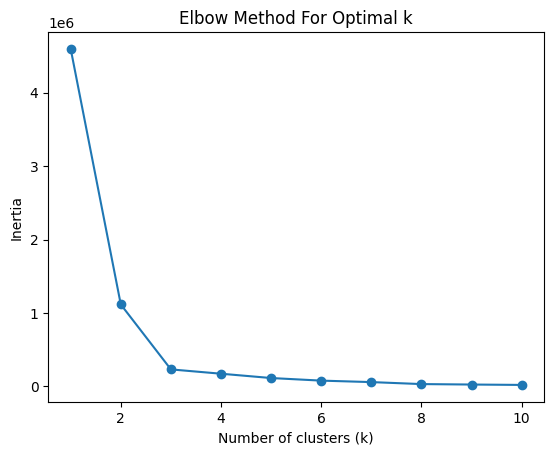

In [40]:
inertias_medi = []
K = range(1, 11)

for k in K:
    kmeans_m = KMeans(n_clusters=k, random_state=42)
    kmeans_m.fit(reduced_data_medi)  # use reduced TF-IDF data (from TruncatedSVD)
    inertias_medi.append(kmeans_m.inertia_)

plt.plot(K, inertias_medi, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

In [41]:
num_clusters= 3
kmeans_m = KMeans(n_clusters=num_clusters, n_init=5, max_iter=500, random_state=42)
kmeans_m.fit(vectorized_words_medi)

KMeans(max_iter=500, n_clusters=3, n_init=5, random_state=42)

C:\Users\smahmood\AppData\Local\Temp\ipykernel_16252\2819449684.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


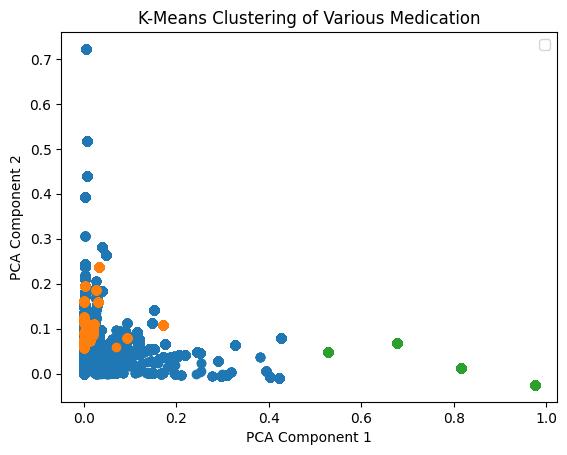

In [42]:
for i in range(num_clusters):
    plt.scatter(reduced_data_medi[kmeans_m.labels_ == i, 0], 
                reduced_data_medi[kmeans_m.labels_ == i, 1], 
                )

plt.legend()
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Clustering of Various Medication')
plt.show()

In [43]:
df_medi['medication_usage_cluster'] = kmeans_m.labels_
#add proc cluster here
print(df_medi['medication_usage_cluster'].value_counts())

medication_usage_cluster
0    34764931
2     4554267
1     3489395
Name: count, dtype: int64


In [59]:
df_medi_encoded = pd.get_dummies(df_medi,columns= ['medication_usage_cluster'],dtype = int)
df_medi_encoded.drop(columns=['medication','event_txt','medication_usage'], inplace= True)

In [60]:
df_medi_encoded = df_medi_encoded.groupby(['hadm_id', 'subject_id']).agg({
'medication_usage_cluster_0':'sum',
'medication_usage_cluster_1':'sum',
'medication_usage_cluster_2':'sum',
}).reset_index()

In [65]:
df_medi_encoded['hadm_id'] = df_medi_encoded['hadm_id'].astype(int)
df_admit_diagnosis_encoded['hadm_id'] = df_admit_diagnosis_encoded['hadm_id'].astype(int)
df_admit_diagnosis_encoded.head()

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2,readmission,anchor_age,gender
0,20001596,15327072,4,10,13,3,7,5,1,1,0,65,1
1,20001633,18030855,5,2,6,0,28,7,0,0,0,28,0
2,20001747,12270767,6,8,7,1,28,9,1,0,0,91,0
3,20001770,10117812,5,10,11,0,28,21,1,0,0,35,0
4,20001800,11828074,4,2,13,4,28,5,1,0,0,59,1


In [66]:
# Merge both encoded tables

df_full_dataset = pd.merge(
    df_admit_diagnosis_encoded,
    df_medi_encoded[['hadm_id', 'medication_usage_cluster_0', 'medication_usage_cluster_1', 'medication_usage_cluster_2']],
    how='left',
    on='hadm_id'
)


In [67]:
df_full_dataset.head()

,hadm_id,subject_id,admission_type,admission_location,discharge_location,insurance,race,diagnosis_proc_cluster_0,diagnosis_proc_cluster_1,diagnosis_proc_cluster_2,readmission,anchor_age,gender,medication_usage_cluster_0,medication_usage_cluster_1,medication_usage_cluster_2
0,20001596,15327072,4,10,13,3,7,5,1,1,0,65,1,8.0,0.0,0.0
1,20001633,18030855,5,2,6,0,28,7,0,0,0,28,0,NaN,NaN,NaN
2,20001747,12270767,6,8,7,1,28,9,1,0,0,91,0,51.0,2.0,18.0
3,20001770,10117812,5,10,11,0,28,21,1,0,0,35,0,378.0,11.0,49.0
4,20001800,11828074,4,2,13,4,28,5,1,0,0,59,1,NaN,NaN,NaN


Build Logistic Regression Model

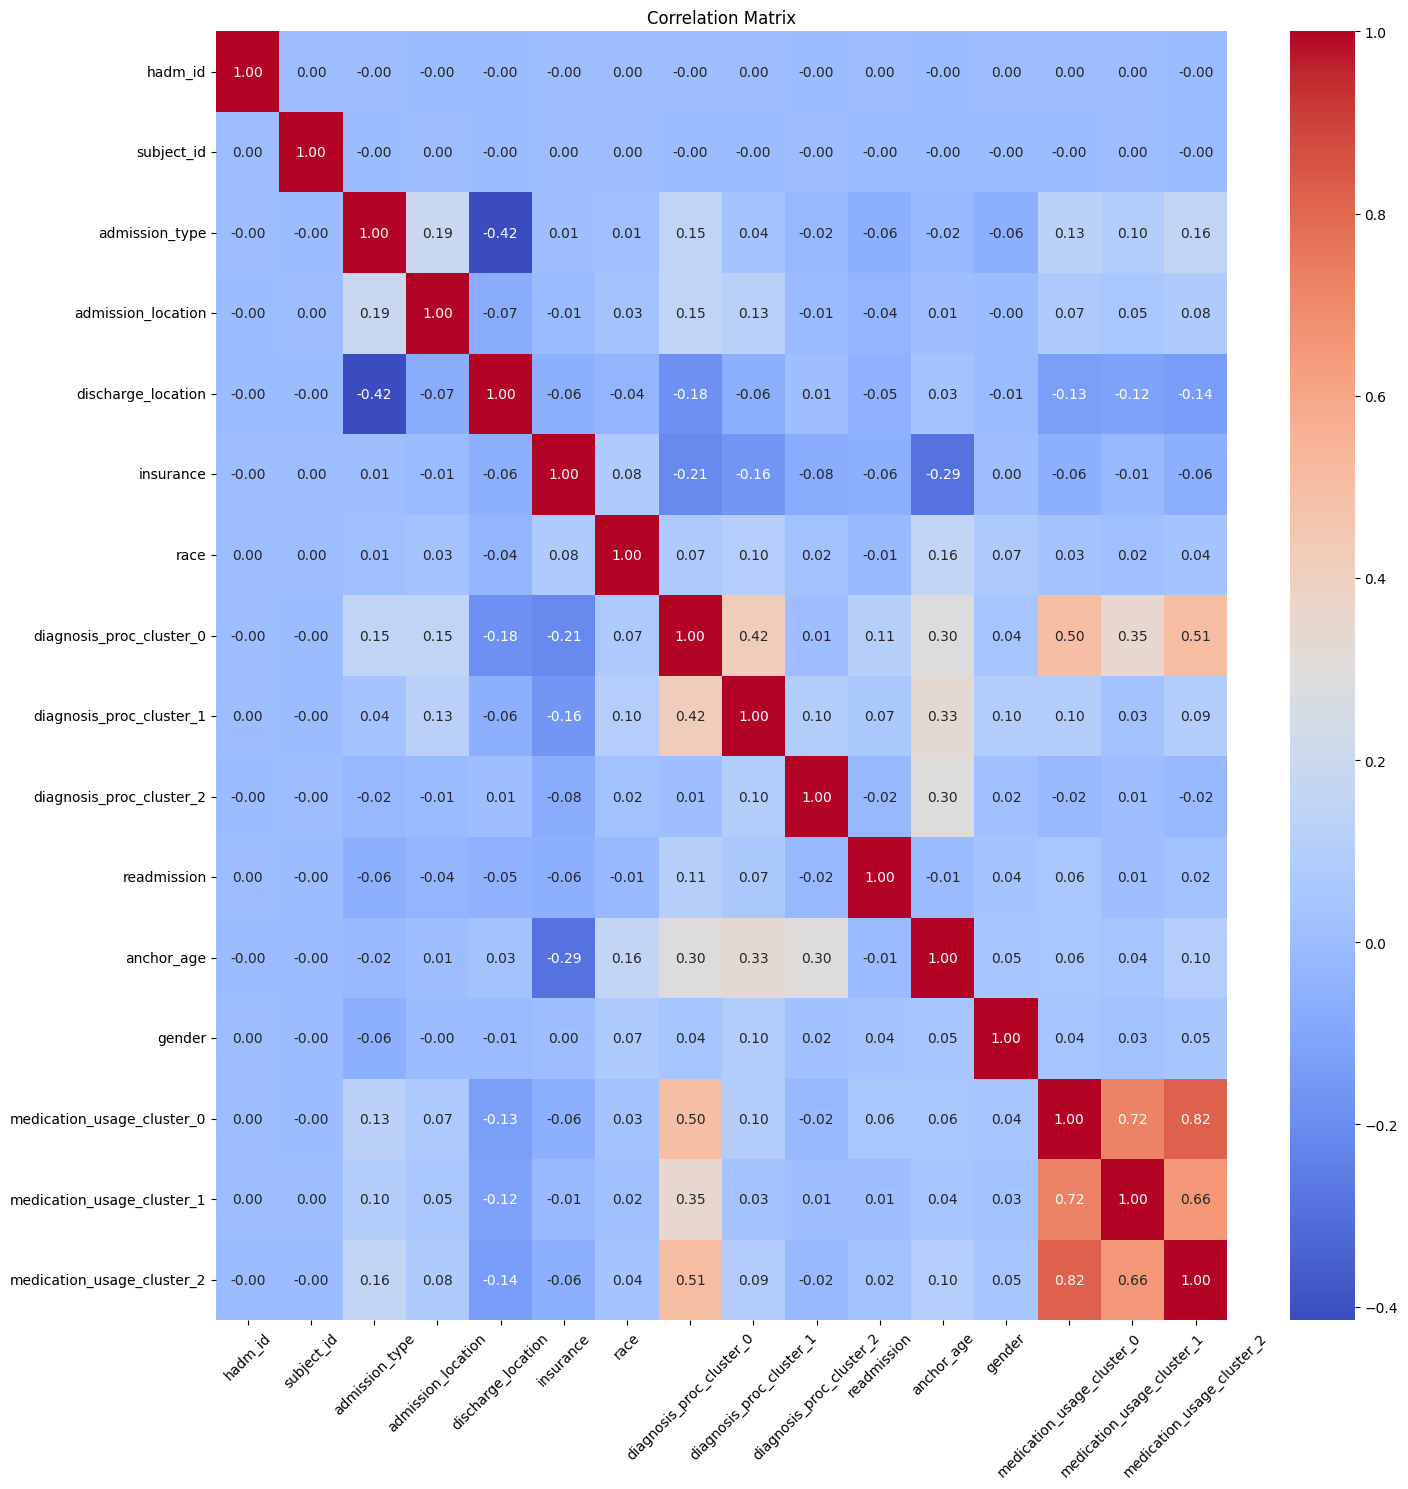

In [74]:
# correlation matrix
corr_matrix = df_full_dataset.corr()

plt.figure(figsize=(15, 15))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()